# First Panel
This first panel includes the image of a single trajectory timeslice (for legend/labeling purposes) as well as a before and after trajectory showing the results of the data preparation for the neurel net

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy

2025-11-19 08:25:57,576 [INFO] 
Limited Linear Model Support Detected! 
---> PYCHEBFUN is not installed. 
---> Install pychebfun to use chebfun derivatives (https://github.com/pychebfun/pychebfun/) 
You can still use other methods 

/home/nehal/.emacs.d/Projects/Software/drosophila_body_orientation_predictor/Notebooks/helper_functions.py:142: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fly_trajectory_and_body["heading_angle"] = corrected_heading_angle
/home/nehal/.emacs.d/Projects/Software/drosophila_body_orientation_predictor/Notebooks/helper_functions.py:190: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:

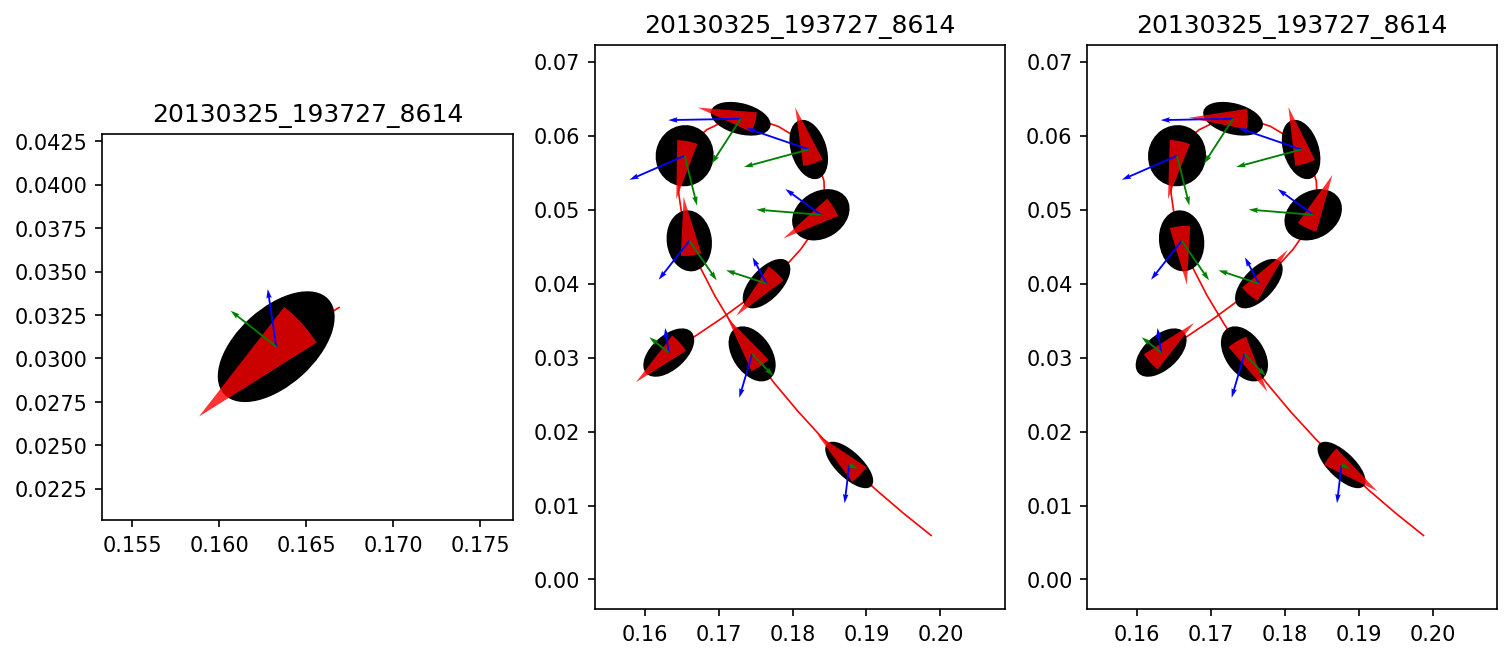

In [2]:
# plot specific trajectory by id
from helper_functions import plot_trajectory,naive_heading_correction,convex_opt_heading_correction,smooth_trajectory
augmented_all_fly_data = pd.read_csv(f'../ExperimentalData/all_wind_heading_and_trajectories_augmented.csv')
heading_and_trajectory_by_id = [group for _, group in augmented_all_fly_data.groupby('trajec_objid')] 
test_trajec = augmented_all_fly_data.loc[augmented_all_fly_data["trajec_objid"]=="20130325_193727_8614"]
fig, axs = plt.subplots(1, 3, figsize=(12, 12), dpi=150)
plot_trajectory(axs[0],pd.DataFrame(test_trajec.iloc[0:2]),legend=False)
plot_trajectory(axs[1],test_trajec,legend=False)
plot_trajectory(axs[2],smooth_trajectory(convex_opt_heading_correction(naive_heading_correction(test_trajec))),legend=False)

# Second Panel
Heat maps of estimator performance

2025-11-19 08:25:58.352880: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-19 08:25:58.353695: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-19 08:25:58.355975: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-19 08:25:58.360118: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-19 08:25:58.369957: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step


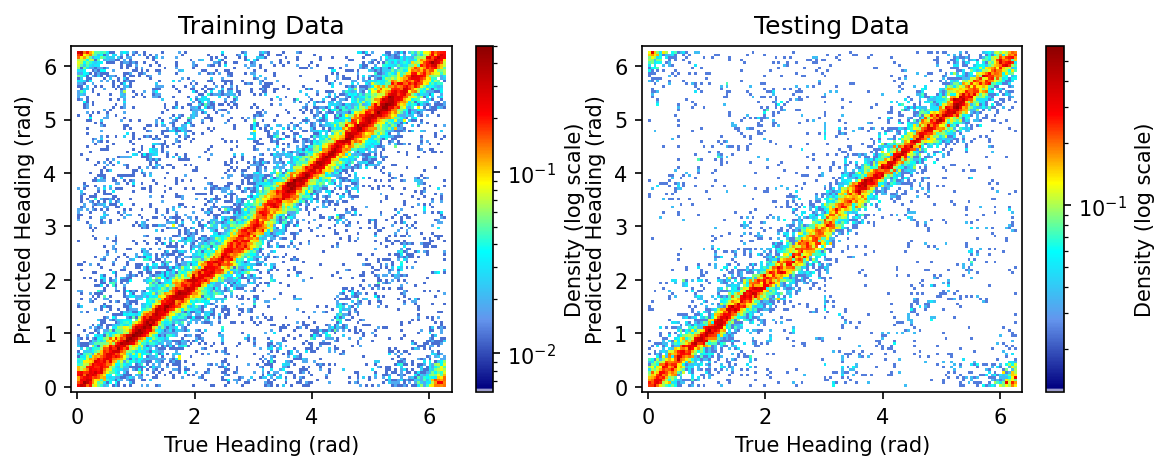

In [3]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
from helper_functions import custom_density_plots
aug_traj = pd.read_csv("augmented_fly_data.csv")
n_input = 24
# Input data
X = aug_traj.iloc[:, 0:n_input]
# Output data
y = aug_traj.iloc[:, n_input:]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

best_estimator = load_model('model_CEM_all-angle-rotate.keras')

from matplotlib.colors import ListedColormap, LinearSegmentedColormap
def make_color_map(color_list=None, color_proportions=None, N=256):
    """ Make a colormap from a list of colors.
    """

    if color_list is None:
        color_list = ['white', 'deepskyblue', 'mediumblue', 'yellow', 'orange', 'red', 'darkred']

    if color_proportions is None:
        color_proportions = np.linspace(0.01, 1, len(color_list) - 1)
        v = np.hstack((np.array(0.0), color_proportions))
    elif color_proportions == 'even':
        color_proportions = np.linspace(0.0, 1, len(color_list))
        v = color_proportions

    l = list(zip(v, color_list))
    cmap = LinearSegmentedColormap.from_list('rg', l, N=N)

    return cmap

cmap = make_color_map(color_list=['white', 'navy', 'cornflowerblue', 'aqua', 'yellow', 'red', 'darkred'], N=256)

fig, axs = plt.subplots(1, 2, figsize=(9, 3), dpi=150)
custom_density_plots([axs[0],axs[1]],[X_train,X_test],[y_train,y_test],best_estimator,cmap,titles=["Training Data", "Testing Data"])

# Third Panel

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


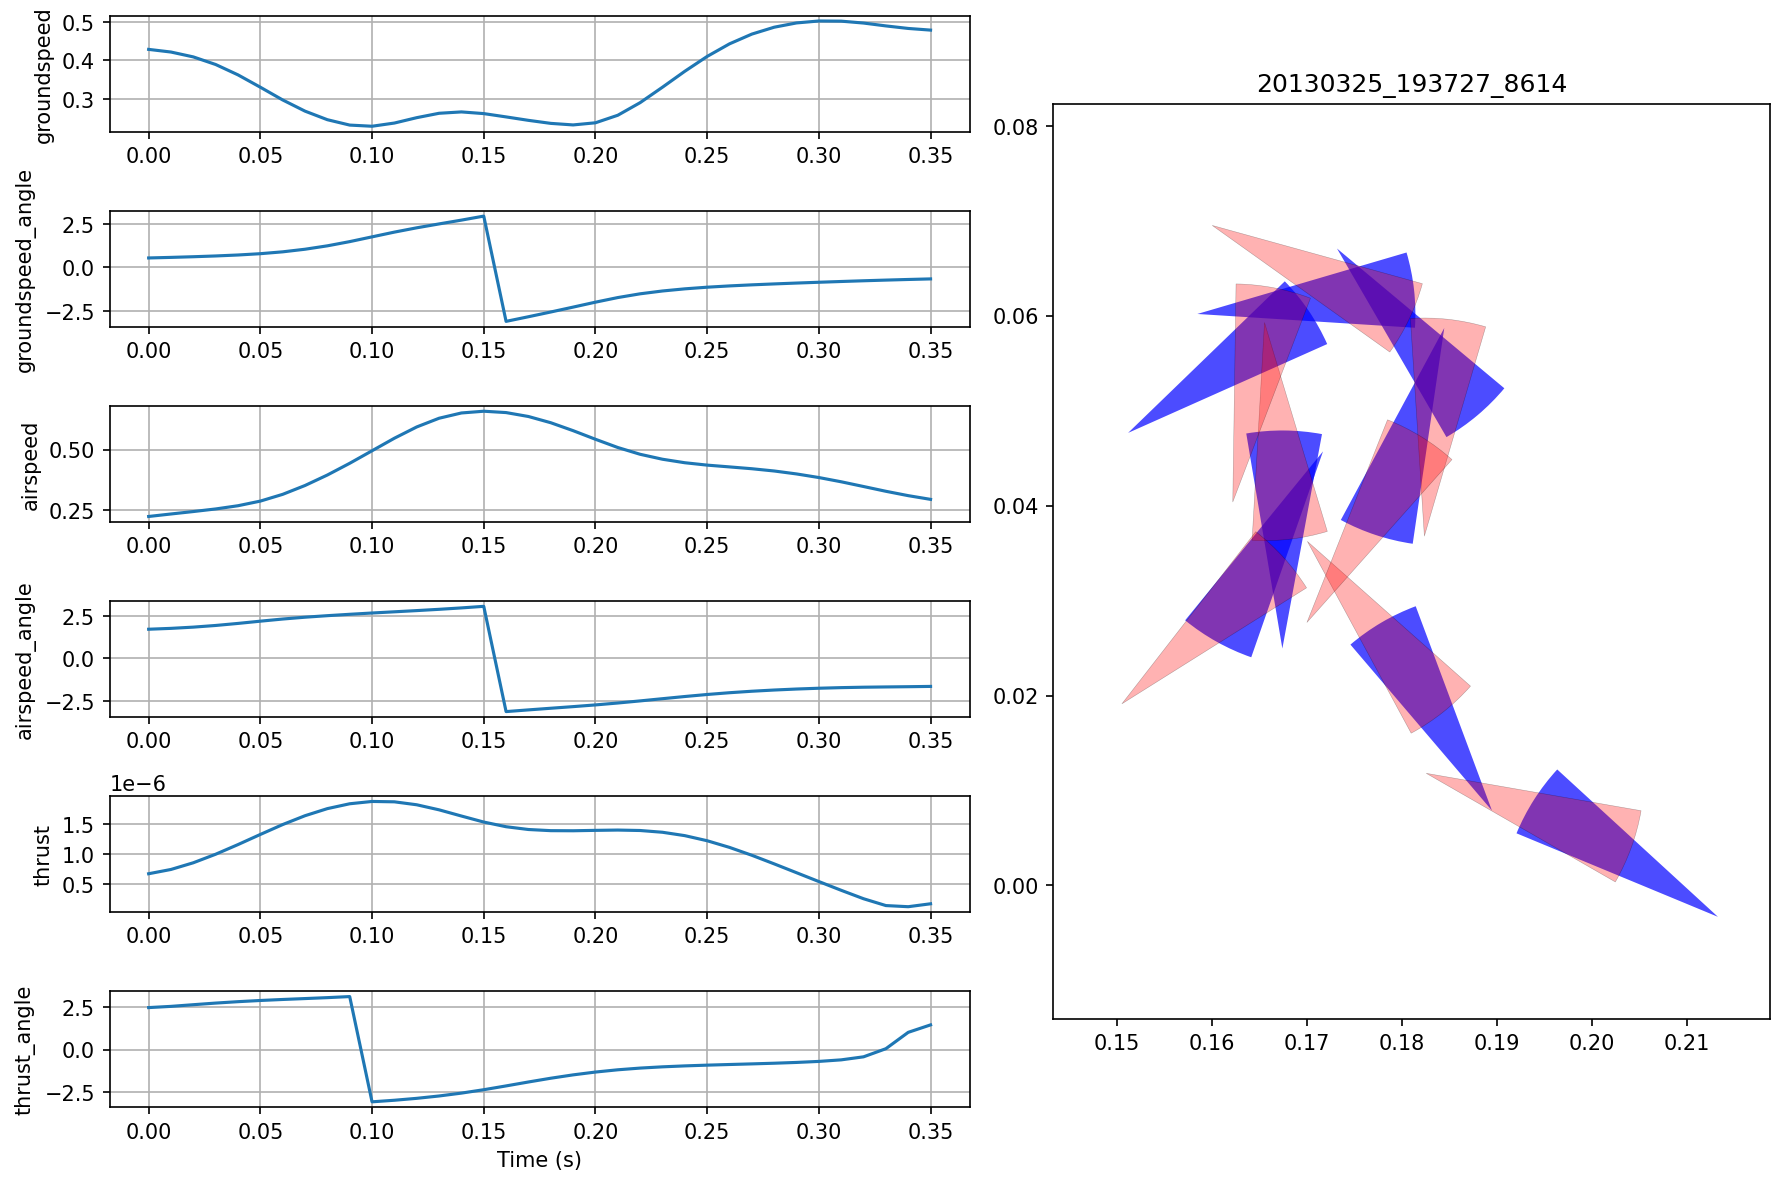

In [4]:
from matplotlib.gridspec import GridSpec
from helper_functions import plot_trajectory_with_predicted_heading,plot_fly_inputs_stacked

best_estimator = load_model('model_CEM_all-angle-rotate.keras')

test_trajec = augmented_all_fly_data.loc[augmented_all_fly_data["trajec_objid"]=="20130325_193727_8614"]


# Same input_cols as above
input_cols = [
    'groundspeed',
    'groundspeed_angle',
    'airspeed',
    'airspeed_angle',
    'thrust',
    'thrust_angle',
]
n_rows_left = len(input_cols)

fig = plt.figure(figsize=(12, 8), dpi=150)
gs = GridSpec(n_rows_left, 2, figure=fig, width_ratios=[1.2, 1])

# Left column: one axis per input, stacked
axes_left = []
for i in range(n_rows_left):
    if i == 0:
        ax = fig.add_subplot(gs[i, 0])
    else:
        ax = fig.add_subplot(gs[i, 0], sharex=axes_left[0])
    axes_left.append(ax)

# Right column: trajectory plot spanning all rows
ax_right = fig.add_subplot(gs[:, 1])

time_window = 4

input_names = [
    'groundspeed',
    'groundspeed_angle',
    'airspeed',
    'airspeed_angle',
    'thrust',
    'thrust_angle',
]

output_names = ['heading_angle_x', 'heading_angle_y']

time_augmentation_kwargs = {
    "time_window": time_window,
    "input_names": input_names,
    "output_names": output_names,
    "direction": "backward"
}

# --- Right: predicted trajectory (with predicted/actual heading) ---
plot_trajectory_with_predicted_heading(
    test_trajec,
    ax_right,
    n_input=n_input,
    best_estimator=best_estimator,
    include_id=True,
    nskip=4,
    plt_show=False,
    smooth=True,
    **time_augmentation_kwargs
)

# --- Left: stacked inputs only ---
plot_fly_inputs_stacked(test_trajec, axes=axes_left)

plt.tight_layout()
plt.show()